In [26]:
import xarray as xr
import geopandas as gpd
import numpy as np
import shapely as sp
from shapely.ops import unary_union


In [10]:
fishing_area = gpd.read_file("./data/available_SWA_fishing_area.geojson")
SWA_land = gpd.read_file("./data/SWA_land.geojson")
eez_fk = gpd.read_file("./data/eez_fk.geojson")

In [11]:
#The xarray grid
min_lon, min_lat, max_lon, max_lat = [-69.61, -60., -50., -32.45] 
res = 0.125# Target resolution (degrees)
new_lons = np.arange(min_lon, max_lon + res, res)
new_lats = np.arange(min_lat, max_lat + res, res)
lon2d, lat2d = np.meshgrid(new_lons, new_lats)


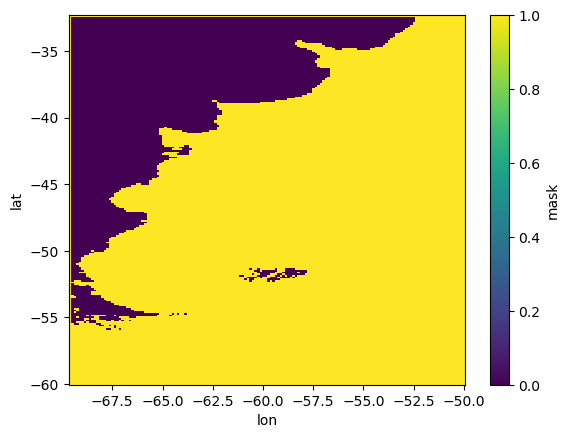

In [12]:
land_geom = SWA_land.geometry.union_all()
inside = sp.contains_xy(land_geom, lon2d, lat2d) #the mask
mask = np.where(inside, 0, 1) #where true put 0, false 1
land_mask_ds = xr.Dataset(
    data_vars={
        "mask": (("lat", "lon"), mask)
    },
    coords={
        "lat": new_lats,
        "lon": new_lons
    }
)

land_mask_ds["mask"].plot()

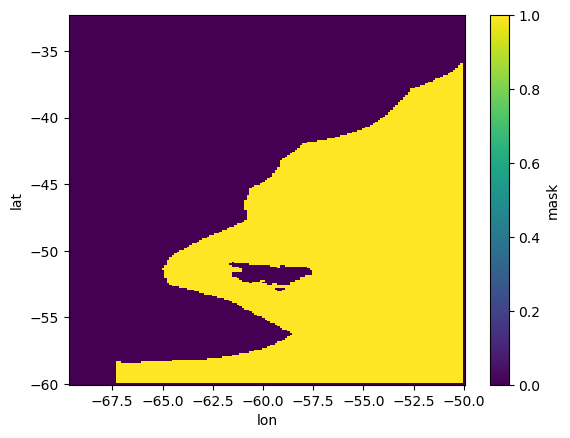

In [ ]:
fishing_area_geom = fishing_area.geometry.union_all()
inside = sp.contains_xy(fishing_area_geom, lon2d, lat2d) #the mask
mask = np.where(inside, 1, 0) #where true put 0, false 1
fishing_area_mask_ds = xr.Dataset(
    data_vars={
        "mask": (("lat", "lon"), mask)
    },
    coords={
        "lat": new_lats,
        "lon": new_lons
    }
)

fishing_area_mask_ds["mask"].plot()

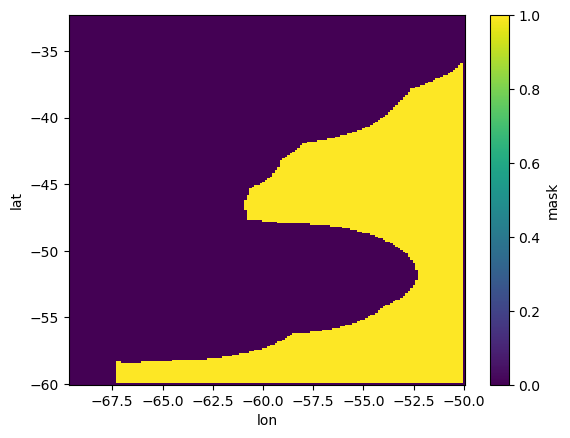

In [ ]:

eez_geom = unary_union(eez_fk.geometry)
diff_geom = fishing_area_geom.difference(eez_geom)#we substract the EEZ from the available fishing area for masking

inside = sp.contains_xy(diff_geom, lon2d, lat2d) #the mask
mask = np.where(inside, 1, 0) #where true put 0, false 1
eez_fk_mask_ds = xr.Dataset(
    data_vars={
        "mask": (("lat", "lon"), mask)
    },
    coords={
        "lat": new_lats,
        "lon": new_lons
    }
)

eez_fk_mask_ds["mask"].plot()

In [15]:
fishing_area_mask_ds.to_netcdf("./data/processed/static/fishing_area_mask.nc")
land_mask_ds.to_netcdf("./data/processed/static/ocean_mask.nc")
eez_fk_mask_ds.to_netcdf("./data/processed/static/eez_fk_mask.nc")
